# Training an LSTM plant model for Neural MPC: Cascaded Two-Tank System

This notebook is the companion to `lstm_training.py`. It identifies a recurrent
neural network (an LSTM) that the Neural MPC controller in `neural_mpc_cts.py`
uses as its prediction model.

### Estimating the initial hidden state

A recurrent model needs an initial hidden state $(h_0, c_0)$. Inside an MPC we
cannot afford a long zero-state transient at every solve, so we estimate
$(h_0, c_0)$ from a short window of recent measurements by teacher forcing, then
score the model only on predictions made after that warmup. This warmup lets
recurrent dynamics run inside a constrained MPC, and `CasadiLSTM` repeats the same
numeric warmup at deployment.

The notebook calls into `lstm_training.py`, so every value here is the script's
own; running it reproduces the same model.

**References.** Forgione & Piga (2021): initial-state estimation for RNN system
identification. Adhau et al. (2024): neural-MPC benchmark on this plant.

## 0. Imports

The notebook lives next to `lstm_training.py`; we import it as `lt` and reuse its configuration, data pipeline, model, training loop and plotting helpers.

In [1]:
%matplotlib inline
import inspect
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

# Make the example directory importable, then import the training module.
import sys
sys.path.insert(0, str(Path.cwd()))
import lstm_training as lt
from torch_wrapper import LSTM

## 1. Configuration

The hyper-parameters live at the top of `lstm_training.py`. The ones that matter
for the technique:

| Symbol | Variable | Meaning |
|---|---|---|
| $H$ | `HIDDEN_SIZE` | LSTM hidden-state width |
| $n_c$ | `N_CONTEXT` | context-window length used to estimate $(h_0, c_0)$ |
| $W$ | `WINDOW_SIZE` | training-window length (context + prediction) |
| — | `STRIDE` | step between consecutive windows |
| $\alpha$ | `Q_REG` | weight of the state-consistency term on the warmup region |

Set `RUN_TRAINING = False` to skip training and load the shipped model for the
evaluation plots. When `True`, the notebook trains a fresh model and saves it to
`models/<REPRO_MODEL_NAME>.pt`, leaving the shipped `models/<MODEL_NAME>.pt` (the
model the controller consumes) untouched.

In [2]:
lt.RUN_TRAINING = True  # set to False to load the shipped model and only plot

for k in ["HIDDEN_SIZE", "N_CONTEXT", "WINDOW_SIZE", "STRIDE", "BATCH_SIZE",
          "LR", "Q_REG", "NORMALIZE_DATA", "MODEL_NAME", "REPRO_MODEL_NAME"]:
    print(f"{k:>16} = {getattr(lt, k)}")

     HIDDEN_SIZE = 128
       N_CONTEXT = 5
     WINDOW_SIZE = 100
          STRIDE = 2
      BATCH_SIZE = 32
              LR = 0.002
           Q_REG = 0.1
  NORMALIZE_DATA = False
      MODEL_NAME = cts-lstm-batched-128
REPRO_MODEL_NAME = cts-lstm-batched-128-repro


## 2. The benchmark dataset

The cascaded two-tank benchmark ($T_s = 4\,$s) provides one **estimation**
experiment (`uEst`/`yEst`) for training and a separate **test** experiment
(`uVal`/`yVal`) for evaluation. The input is the pump voltage; the output is the
level $h_2$ of the lower tank.

We fix the seeds first: the only randomness is the LSTM weight initialisation and
the shuffled mini-batches, so seeding here (before any of those) makes the run
reproducible.

Using device: cuda
estimation samples: 1024  test samples: 1024


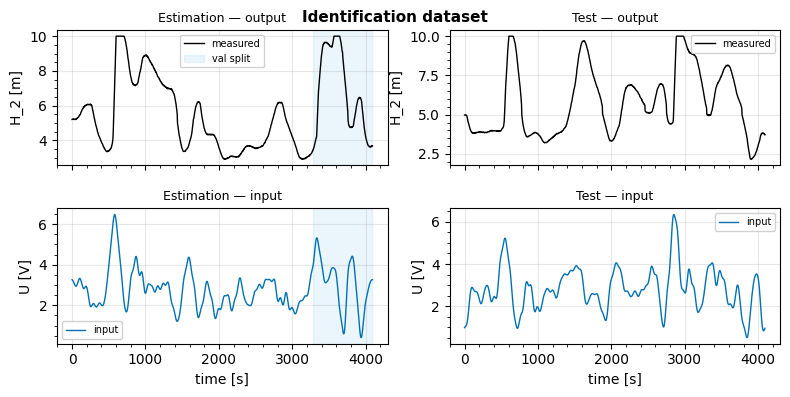

In [3]:
np.random.seed(0)
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

u_est, y_est, u_test, y_test = lt.load_engineering_data()
split_idx = int(u_est.shape[0] * lt.SPLIT_RATIO)
print("estimation samples:", u_est.shape[0], " test samples:", u_test.shape[0])

lt.plot_dataset(u_est, y_est, u_test, y_test, split_idx)
plt.show()

## 3. From one long sequence to training windows

We cannot backprop through the whole 800-sample experiment at once, so we cut the
estimation sequence into short overlapping windows of length $W$ (`STRIDE` apart).
The first `SPLIT_RATIO` of the sequence builds the **training** windows and the
rest the **validation** windows (shaded above).

Each window is split in two:

* the first $n_c$ samples: the context/warmup region, teacher-forced with the
  measured output to estimate $(h_0, c_0)$;
* the remaining $W - n_c$ samples: the free-running prediction region, the part
  the loss scores.

The plot below shows one window with this split before any training.

train windows: 360  val windows: 53
n_inputs: 1  n_outputs: 1


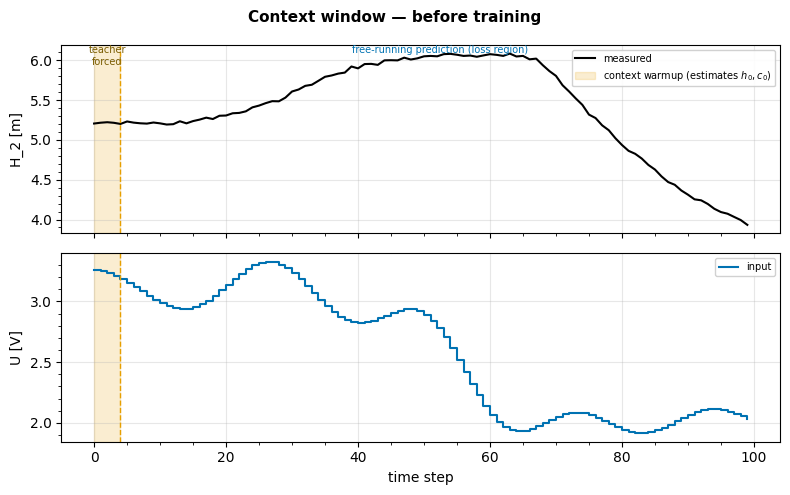

In [4]:
train_loader, val_loader, split_idx, n_inputs, n_outputs = lt.make_windowed_loaders(u_est, y_est)
print("train windows:", len(train_loader.dataset), " val windows:", len(val_loader.dataset))
print("n_inputs:", n_inputs, " n_outputs:", n_outputs)

lt.plot_context_window(y_est, u_est, lt.N_CONTEXT, zoom_len=lt.WINDOW_SIZE,
                       y_sim=None, title="Context window — before training")
plt.show()

## 4. The LSTM with context-based state estimation

The model (`torch_wrapper/lstm_pytorch.py`) is a single-layer LSTM with a projection so its output dimension equals the number of measured signals. Its `forward` runs in two phases:

1. `estimate_state`: for the first $n_c$ steps it replaces the layer's hidden state with the measured output (teacher forcing), producing the estimated $(h_0, c_0)$;
2. `predict_state`: from that state the model runs free over the rest of the window using only the inputs.

Both phases appear below.

In [5]:
print(inspect.getsource(LSTM.estimate_state))
print(inspect.getsource(LSTM.predict_state))

    def estimate_state(self, u_train, y_train, nstep):
        """Estimate LSTM hidden state using measured outputs over context window.

        Parameters
        ----------
        u_train : torch.Tensor
            Input sequence for state estimation.
        y_train : torch.Tensor
            Measured output sequence used to warm up hidden states.
        nstep : int
            Number of context steps for state estimation.

        Returns
        -------
        y_sim : torch.Tensor
            Estimated outputs over context window.
        """
        if len(u_train.shape) == 2:
            u_train = u_train.view(self.batch_size, u_train.shape[0], self.n_inputs)
        if len(y_train.shape) == 2:
            y_train = y_train.view(self.batch_size, y_train.shape[0], self.n_outputs)

        y_est = []
        device = u_train.device
        hn = torch.zeros(
            1, u_train.size(0), self.n_outputs, requires_grad=True, device=device
        )
        cn = torch.zeros(
   

## 5. The training loss

The composite loss splits the window at $n_c$:

$$\mathcal{L} = \underbrace{Q_{\mathrm{mse}}\,\mathrm{MSE}\big(\hat y_{n_c:},\,y_{n_c:}\big)}_{\text{prediction}}
 + \underbrace{\alpha\,\mathrm{MSE}\big(\hat y_{:n_c},\,y_{:n_c}\big)}_{\text{state consistency}}
 + Q_{\mathrm{ybox}}\,\mathcal{L}_{\mathrm{box}}.$$

The first term is the prediction error that matters for control. The second
(Forgione & Piga's regularisation analogue) keeps the warmup output consistent
with the measured dynamics so the estimated $(h_0, c_0)$ is meaningful. The
optional box term keeps predictions inside physical bounds.

In [6]:
print(inspect.getsource(lt.compute_loss))

def compute_loss(y_sim, y_true, n_context, num_outputs, y_box_lo, y_box_hi):
    """Composite training loss, split into context-warmup and prediction parts.

    The sequence is divided at ``n_context``:

    * ``[n_context:]`` is the free-running **prediction** region: the
      mean-squared error that matters for control (``L_mse``).
    * ``[:n_context]`` is the teacher-forced **warmup** region whose output is
      penalised by a state-consistency term (``L_reg``), the analogue of the
      Forgione & Piga regularization that keeps the estimated ``(h0, c0)``
      consistent with the measured dynamics.

    ``L_ybox`` is an optional soft penalty keeping predictions inside physical
    bounds. Returns ``(L_mse, L_reg, L_ybox, total)``.
    """
    per_step = nn.functional.mse_loss(y_sim, y_true, reduction="none")
    per_step = per_step.view(-1, y_sim.shape[1], num_outputs)
    n_batch = per_step.shape[0]
    seq_len = per_step.shape[1]

    L_mse = per_step[:, n_context:, :].sum() 

## 6. Training

Adam with weight decay, gradient-norm clipping, a `ReduceLROnPlateau` schedule and early stopping on the validation loss. We restore the best validation state before saving.

In [7]:
models_dir = lt._PROJECT_ROOT / "models"
models_dir.mkdir(parents=True, exist_ok=True)

history = None
if lt.RUN_TRAINING:
    model = lt.build_lstm(n_inputs, n_outputs, batch_size=lt.BATCH_SIZE,
                          sequence_length=lt.WINDOW_SIZE, device=device)
    history = lt.train_lstm(model, train_loader, val_loader, n_inputs, n_outputs, device)
    if history["best_state"] is not None:
        model.load_state_dict(history["best_state"])
        print(f"Best model restored (val loss: {history['best_val_loss']:.6f})")
    eval_path = models_dir / f"{lt.REPRO_MODEL_NAME}.pt"
    torch.save(model.state_dict(), eval_path)
else:
    eval_path = models_dir / f"{lt.MODEL_NAME}.pt"
print("evaluation model:", eval_path)

Training:  10%|▉         | 996/10000 [01:18<11:49, 12.69epoch/s, train=0.21338, val=1.34164, lr=1.56e-05, u:d=-2.88, patience=299]

Early stopping at epoch 996.

Training time: 78.47s
Best model restored (val loss: 0.695287)
evaluation model: /tmp/neural-mpcx/examples/Cascaded_Two_Tank_System/models/cts-lstm-batched-128-repro.pt


## 7. Results

### Learning curve

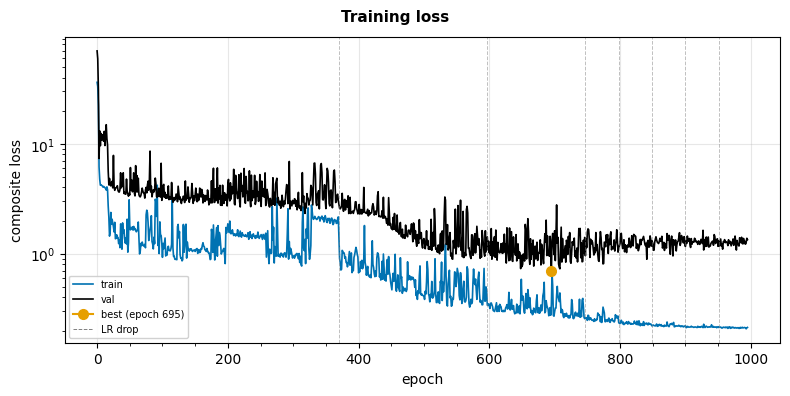

In [8]:
if history is not None:
    lt.plot_loss_curve(history)
    plt.show()
else:
    print("RUN_TRAINING is False — no learning curve to show.")

### Training diagnostics

Borrowed from Karpathy's *makemore part 3*: lightweight signals that show whether
the learning rate and weight initialisation keep training healthy, rather than
tuning them blind.

* **update-to-data ratio** $\log_{10}(|\Delta W| / |W|)$: the fraction by which
  each weight moves per step. The rule of thumb is $\approx 10^{-3}$ (the dashed
  line at $-3$): far below it the weights barely move (init/LR too small), well
  above it the steps are large and noisy.
* **gradient norm** (pre-clip) against the `max_norm = 5` clip threshold: shows
  how often clipping engages.
* **cell-state saturation**: the share of $|\tanh(c)| > 0.97$; when this share
  rises, the recurrence is entering a vanishing-gradient regime.

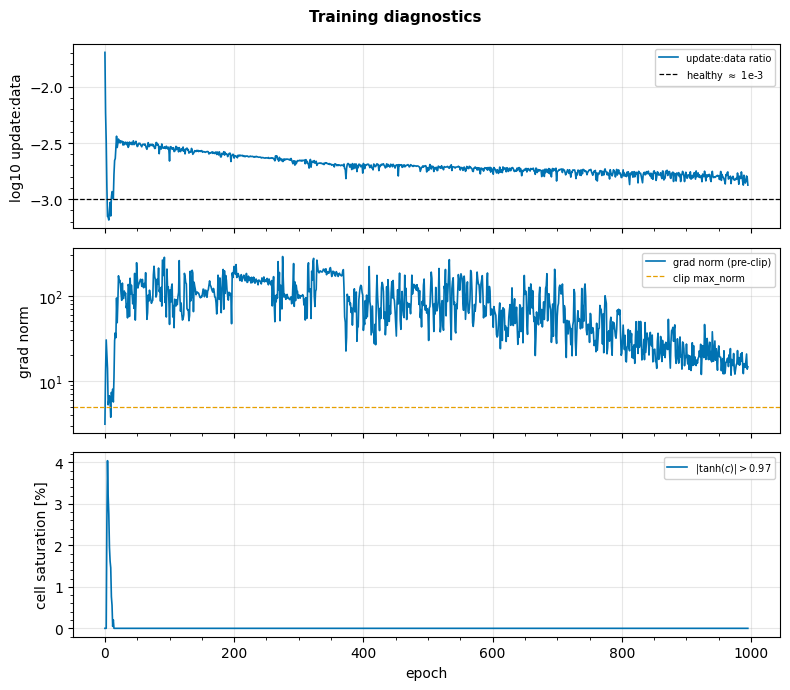

In [9]:
if history is not None:
    lt.plot_diagnostics(history)
    plt.show()
else:
    print("RUN_TRAINING is False — no diagnostics to show.")

### Checking the `std=1e-4` initialisation

The notebook initialises the LSTM weights with a small Gaussian (`std=1e-4`), much
smaller than a variance-preserving ("kaiming") init. For system identification
this choice is deliberate: it starts the model near a quiet, stable map. But a
small init is only healthy if the weights still move during training. We can read
the answer from the update-to-data ratio above: below we check its late-training
median against the $\approx 10^{-3}$ target.

In [10]:
if history is not None:
    ud = np.array(history["ud_history"])
    tail = ud[-min(len(ud), 50):]          # last ~50 epochs
    med = float(np.median(tail))
    print(f"median update:data ratio (late training): {med:.2f}   (target ≈ -3)")
    if med < -4:
        print("→ well below 1e-3: weights barely move. The std=1e-4 init / LR "
              "may be too small — consider a larger init or higher LR.")
    elif med > -2:
        print("→ above 1e-2: steps are large/noisy — consider lowering the LR.")
    else:
        print("→ near 1e-3: init scale and LR look healthy; keep std=1e-4.")
else:
    print("RUN_TRAINING is False — train a model to evaluate the init scale.")

median update:data ratio (late training): -2.81   (target ≈ -3)
→ near 1e-3: init scale and LR look healthy; keep std=1e-4.


### Open-loop fit

We simulate the full estimation and test sequences. The model warms up on the first $n_c$ samples, then runs free; we report $R^2$ and RMSE on the prediction region and mark the context boundary on every panel.

In [11]:
y_sim_train, r2_tr, rmse_tr = lt.rollout_full_sequence(eval_path, u_est, y_est, n_outputs, device)
y_sim_test,  r2_te, rmse_te = lt.rollout_full_sequence(eval_path, u_test, y_test, n_outputs, device)
print("Train R^2:", np.atleast_1d(r2_tr), " RMSE:", np.atleast_1d(rmse_tr))
print("Test  R^2:", np.atleast_1d(r2_te), " RMSE:", np.atleast_1d(rmse_te))

Train R^2: [0.9647215]  RMSE: [0.407635]
Test  R^2: [0.9633931]  RMSE: [0.4025192]


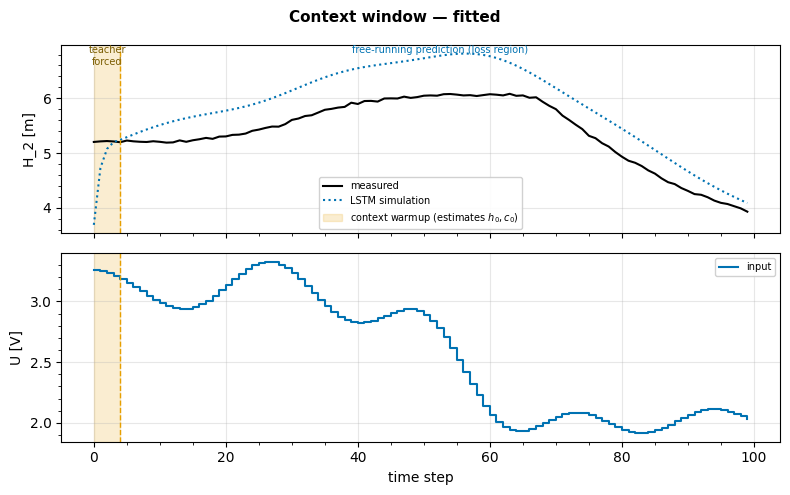

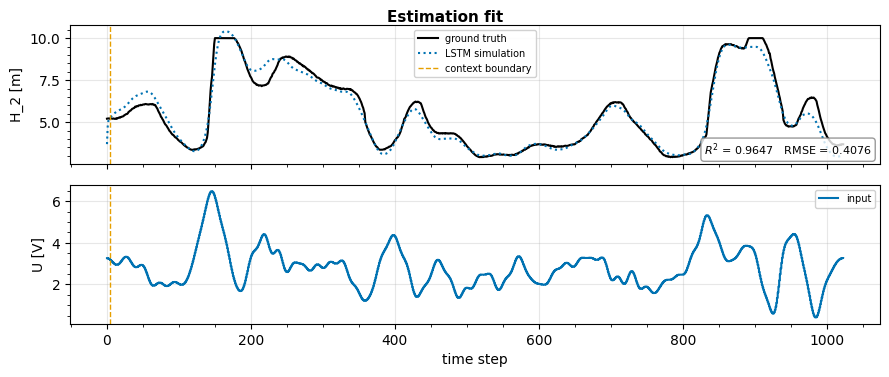

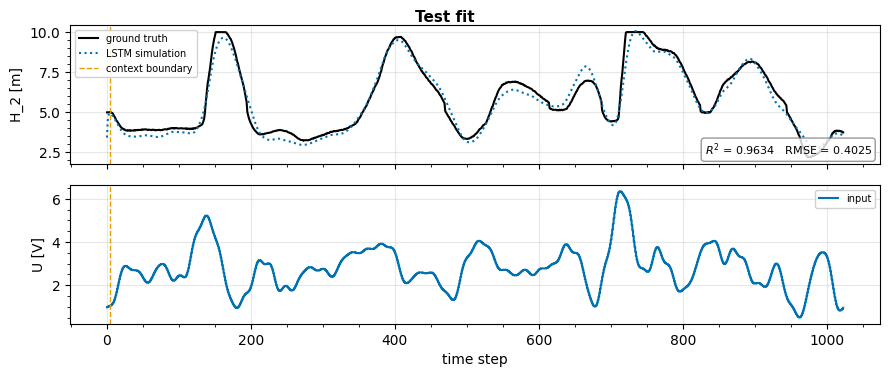

In [12]:
lt.plot_context_window(y_est, u_est, lt.N_CONTEXT, zoom_len=lt.WINDOW_SIZE,
                       y_sim=y_sim_train, title="Context window — fitted")
lt.plot_fit(y_est, y_sim_train, u_est, r2_tr, rmse_tr, title="Estimation fit")
lt.plot_fit(y_test, y_sim_test, u_test, r2_te, rmse_te, title="Test fit")
plt.show()

## 8. Using the model in Neural MPC

The saved `.pt` loads directly into the controller. In `neural_mpc_cts.py` we build
a `CasadiLSTM` with the same `n_context`, `hidden_size` and `proj_size`, load the
state dict, and register it as the MPC prediction model with `set_neural_dynamics`:

```python
model = CasadiLSTM(n_context, n_inputs, hidden_size=HIDDEN_SIZE, horizon=HORIZON, proj_size=1)
model.load_state_dict(torch.load("models/cts-lstm-batched-128.pt", map_location="cpu"))
mpc.set_neural_dynamics(model=model, output_bias=b, name="F_neural", n_warmup=1)
```

At every MPC step the controller repeats the context-window warmup to refresh
$(h_0, c_0)$ from the latest measurements, the same mechanism trained above.